## 라이브러리 불러오기

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets

## 학습에 이용할 장치 설정

In [ ]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print("사용할 PyTorch 버전:", torch.__version__,' Device:', DEVICE)

# 한번 학습시 몇개의 사진을 이용하는지
BATCH_SIZE = 32
# 학습을 몇번 할 건지
EPOCHS = 10

사용할 PyTorch 버전: 2.13.0+cu130  Device: cpu


/home/kim/Desktop/YoungJae/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 데이터 불러오기

In [ ]:
train_dataset = datasets.MNIST(root = "./data/MNIST",
                               train = True,
                               download = True,
                               transform = transforms.ToTensor())

test_dataset = datasets.MNIST(root = "./data/MNIST",
                              train = False,
                              transform = transforms.ToTensor())

# BATCH_SIZE 크기만큼 분리
train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                           batch_size = BATCH_SIZE,
                                           shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = BATCH_SIZE,
                                          shuffle = False)

## 데이터 개수 및 형태 확인

In [14]:
len(train_dataset), len(test_loader)

(60000, 313)

In [4]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor


## 데이터 확인

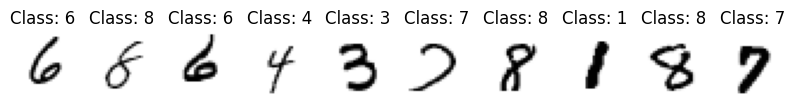

In [5]:
pltsize = 1
plt.figure(figsize=(10 * pltsize, pltsize)) #10개 plot하기 위한 figure 크기 설정

for i in range(10):
    plt.subplot(1, 10, i + 1) # plot.subplot(rows, columns, index)
    plt.axis('off')
    plt.imshow(X_train[i, :, :, :].numpy().reshape(28, 28), cmap = "gray_r")
    plt.title('Class: ' + str(y_train[i].item()))

## 모델 만들기

모델은 손글씨 숫자 그림을 보고 `이건 0일까? 1일까? ... 9일까?`를 맞히는 기계입니다.

처음부터 어려운 말로 보면 헷갈리니까, 아래처럼 생각하면 됩니다.

| 쉬운 말 | 실제로 하는 일 | 코드에서 보이는 이름 |
|---|---|---|
| 손글씨 그림 보기 | 28 x 28칸짜리 이미지를 받음 | `x` |
| 한 줄로 펼치기 | 그림을 784개 숫자로 바꿈 | `x.view(-1, 28*28)` |
| 단서 찾기 1 | 선, 꺾임, 둥근 모양 같은 특징을 찾음 | `fc1` |
| 단서 정리하기 | 찾은 단서를 한 번 더 정리함 | `fc2` |
| 답 고르기 | 0부터 9까지 중 가장 맞는 숫자를 고름 | `fc3` |

그러니까 `fc1`, `fc2`를 외우려고 하기보다, **그림 속 단서를 찾는 단계**라고 이해하면 됩니다.

![모델 구조 쉬운 그림](images/model_architecture_easy.svg)


In [6]:
class Net(nn.Module): # nn.Module은 모든 neural network의 base class라고 한다. 
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        
    def forward(self,x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        x = F.sigmoid(x)
        x = self.fc2(x)
        x = F.sigmoid(x)
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)
        return x

### 학습시 가중치를 얼마나 수정할 건지 알고리즘 설정 

In [7]:
model = Net().to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
criterion = nn.CrossEntropyLoss()

print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


## 학습 함수

In [8]:
def train(model, train_loader, optimizer, log_interval):
    model.train()
    for batch_idx, (image, label) in enumerate(train_loader):
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        
        if batch_idx % log_interval == 0:
            print("Train epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}".format(
                epoch, batch_idx * len(image),
                len(train_loader.dataset), 100. * batch_idx / len(train_loader),
                loss.item()))

## 검증 함수

In [9]:
def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    
    with torch.no_grad():
        for image, label in test_loader:
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim=True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= (len(test_loader.dataset)/ BATCH_SIZE)
    test_accuracy = 100. * correct/len(test_loader.dataset)
    return test_loss, test_accuracy

## 학습 시작

In [10]:
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer, log_interval = 200)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} %\n".format(
        epoch, test_loss, test_accuracy))

Train epoch: 1 [0/60000 (0%)]	Train Loss: 2.391144
Train epoch: 1 [6400/60000 (11%)]	Train Loss: 2.296908
Train epoch: 1 [12800/60000 (21%)]	Train Loss: 2.275122
Train epoch: 1 [19200/60000 (32%)]	Train Loss: 2.348140
Train epoch: 1 [25600/60000 (43%)]	Train Loss: 2.264099
Train epoch: 1 [32000/60000 (53%)]	Train Loss: 2.290237
Train epoch: 1 [38400/60000 (64%)]	Train Loss: 2.252128
Train epoch: 1 [44800/60000 (75%)]	Train Loss: 2.217819
Train epoch: 1 [51200/60000 (85%)]	Train Loss: 2.300193
Train epoch: 1 [57600/60000 (96%)]	Train Loss: 2.167640

[EPOCH: 1], 	Test Loss: 2.2318, 	Test Accuracy: 18.14 %

Train epoch: 2 [0/60000 (0%)]	Train Loss: 2.268538
Train epoch: 2 [6400/60000 (11%)]	Train Loss: 2.207134
Train epoch: 2 [12800/60000 (21%)]	Train Loss: 2.153891
Train epoch: 2 [19200/60000 (32%)]	Train Loss: 2.095371
Train epoch: 2 [25600/60000 (43%)]	Train Loss: 1.963253
Train epoch: 2 [32000/60000 (53%)]	Train Loss: 1.886746
Train epoch: 2 [38400/60000 (64%)]	Train Loss: 1.683622
Tr

## 마지막 검증과 시각화

지금까지는 모델에게 MNIST 숫자 이미지를 보여주면서 공부를 시켰습니다.
이제 마지막에는 모델이 정말 잘 배웠는지 확인해야 합니다.

쉽게 말하면 이렇게 생각하면 됩니다.

| 단계 | 뜻 |
|---|---|
| 학습 | 문제집을 풀면서 공부하는 과정 |
| 검증 | 처음 보는 시험 문제를 풀어보는 과정 |
| 정확도 | 100문제 중 몇 문제를 맞혔는지 |
| 손실 | 정답과 예측이 얼마나 멀리 떨어져 있는지 |

아래 그림은 테스트 이미지가 모델을 지나 예측 결과가 나오는 흐름입니다.


In [ ]:
# 검증 과정을 한눈에 보기 위한 그림입니다.
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 3))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3)
ax.axis('off')

steps = [
    (0.4, 'Test image', 'New digit\\nimage'),
    (3.0, 'Model', 'Trained neural\\nnetwork'),
    (5.6, 'Prediction', 'Number chosen\\nby model'),
    (8.2, 'Compare', 'Compare with\\ntrue label'),
]

for x, title, desc in steps:
    box = FancyBboxPatch(
        (x, 0.8), 2.0, 1.4,
        boxstyle='round,pad=0.08',
        linewidth=1.5,
        edgecolor='#333333',
        facecolor='#f4f8ff'
    )
    ax.add_patch(box)
    ax.text(x + 1.0, 1.65, title, ha='center', va='center', fontsize=12, weight='bold')
    ax.text(x + 1.0, 1.25, desc, ha='center', va='center', fontsize=10)

for x in [2.45, 5.05, 7.65]:
    ax.annotate('', xy=(x + 0.45, 1.5), xytext=(x, 1.5), arrowprops=dict(arrowstyle='->', lw=2))

ax.text(5.5, 0.25, 'Validation means solving new problems and comparing predictions with true labels.', ha='center', fontsize=11)
plt.tight_layout()
plt.show()




## 1. 최종 정확도 확인

아래 코드는 학습이 끝난 모델을 테스트 데이터로 다시 확인합니다.

- `final_test_loss`: 모델이 얼마나 헷갈렸는지 나타내는 값입니다. 보통 작을수록 좋습니다.
- `final_test_accuracy`: 모델이 몇 퍼센트나 맞혔는지 나타내는 값입니다. 높을수록 좋습니다.

예를 들어 정확도가 `90%`라면, 100문제 중 약 90문제를 맞힌 것입니다.


In [11]:
# 최종 검증: 학습이 끝난 모델의 테스트 데이터 성능을 다시 확인합니다.
final_test_loss, final_test_accuracy = evaluate(model, test_loader)

print(f"최종 검증 손실: {final_test_loss:.4f}")
print(f"최종 검증 정확도: {final_test_accuracy:.2f}%")

최종 검증 손실: 0.3363
최종 검증 정확도: 90.30%


## 2. 어떤 숫자를 잘 맞히고 틀렸는지 보기

정확도 하나만 보면 전체 점수만 알 수 있습니다.
하지만 어떤 숫자에서 많이 틀리는지는 알기 어렵습니다.

그래서 `confusion matrix`를 봅니다.

읽는 방법은 간단합니다.

| 위치 | 뜻 |
|---|---|
| 세로축 True Label | 실제 정답 |
| 가로축 Predicted Label | 모델의 예측 |
| 대각선 숫자 | 맞힌 개수 |
| 대각선 밖 숫자 | 틀린 개수 |

예를 들어 `True Label`이 5인데 `Predicted Label`이 3인 칸이 크다면, 모델이 5를 3으로 자주 헷갈린다는 뜻입니다.


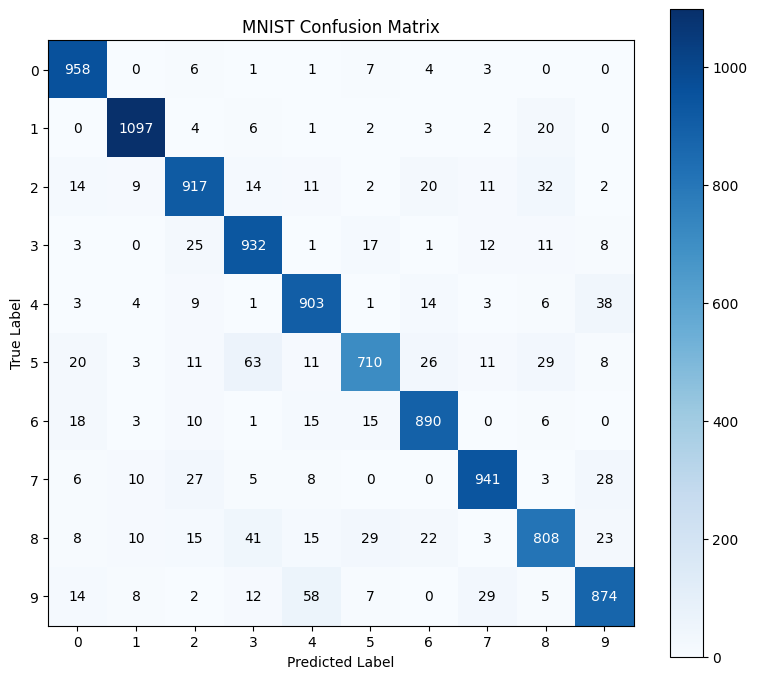

In [12]:
# 숫자별로 얼마나 맞고 틀렸는지 확인하기 위한 혼동 행렬입니다.
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for image, label in test_loader:
        image = image.to(DEVICE)
        output = model(image)
        prediction = output.argmax(dim=1).cpu()

        all_labels.append(label)
        all_predictions.append(prediction)

all_labels = torch.cat(all_labels)
all_predictions = torch.cat(all_predictions)

confusion_matrix = torch.zeros(10, 10, dtype=torch.int64)
for label, prediction in zip(all_labels, all_predictions):
    confusion_matrix[int(label), int(prediction)] += 1

plt.figure(figsize=(8, 7))
plt.imshow(confusion_matrix.numpy(), cmap='Blues')
plt.title('MNIST Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()

max_count = confusion_matrix.max().item()
for row in range(10):
    for col in range(10):
        count = confusion_matrix[row, col].item()
        text_color = 'white' if count > max_count * 0.5 else 'black'
        plt.text(col, row, str(count), ha='center', va='center', color=text_color)

plt.tight_layout()
plt.show()

## 3. 실제 이미지로 확인하기

마지막으로 테스트 이미지 몇 장을 직접 눈으로 확인합니다.

각 그림 위에는 두 가지가 나옵니다.

| 표시 | 뜻 |
|---|---|
| `Pred` | 모델이 예측한 숫자 |
| `True` | 실제 정답 숫자 |

제목 색깔도 의미가 있습니다.

- 초록색: 모델이 맞혔습니다.
- 빨간색: 모델이 틀렸습니다.

이 그림을 보면 모델이 어떤 글씨체를 잘 맞히고, 어떤 글씨체에서 헷갈리는지 쉽게 볼 수 있습니다.


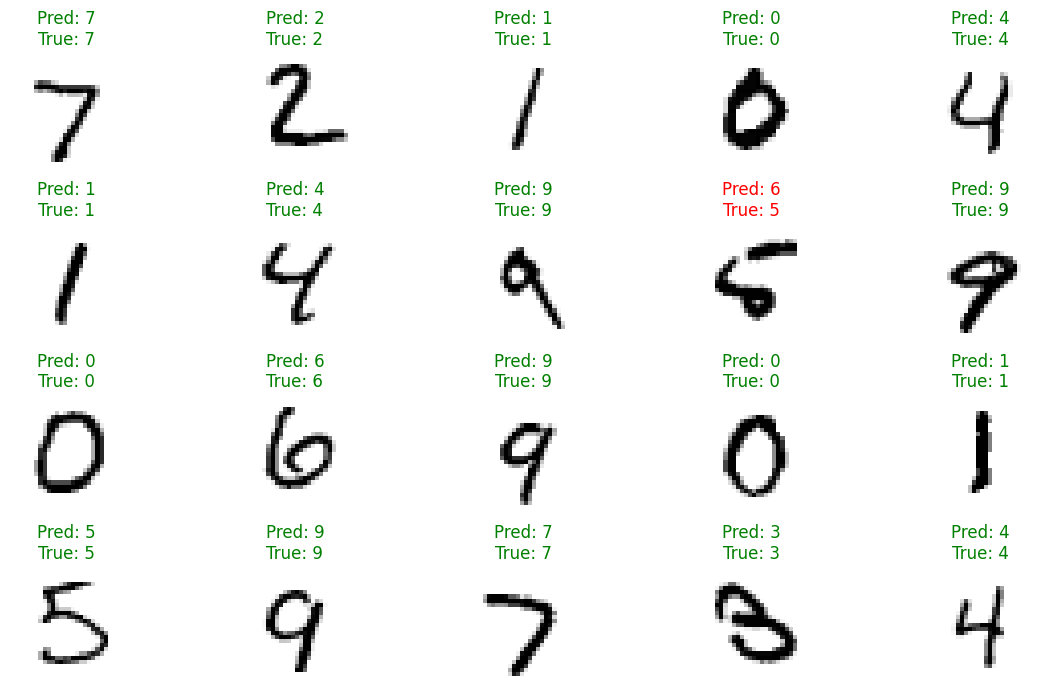

In [13]:
# 테스트 이미지 몇 장을 실제 정답과 모델 예측으로 비교합니다.
sample_images, sample_labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    sample_output = model(sample_images.to(DEVICE))
    sample_predictions = sample_output.argmax(dim=1).cpu()

plt.figure(figsize=(12, 7))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.axis('off')
    plt.imshow(sample_images[i].numpy().reshape(28, 28), cmap='gray_r')

    true_label = sample_labels[i].item()
    predicted_label = sample_predictions[i].item()
    title_color = 'green' if true_label == predicted_label else 'red'
    plt.title(f'Pred: {predicted_label}\nTrue: {true_label}', color=title_color)

plt.tight_layout()
plt.show()

## 정리

마지막 검증과 시각화로 확인한 것은 세 가지입니다.

| 확인한 것 | 알 수 있는 점 |
|---|---|
| 최종 정확도 | 전체적으로 얼마나 잘 맞히는지 |
| 혼동 행렬 | 어떤 숫자끼리 헷갈리는지 |
| 예측 이미지 | 실제로 어떤 그림을 맞히거나 틀렸는지 |

즉, 모델을 만들고 끝내는 것이 아니라, 마지막에 꼭 `얼마나 잘하는지`와 `어디서 틀리는지`를 확인해야 합니다.
